<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/METODO_PARA_DETERMINAR_CUANDO_DETENERSE_AL_GENERAR_NUEVOS_DATOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:purple;"> **METODO PARA DETERMINAR CUANDO DETENERSE AL GENERAR NUEVOS DATOS** </span>

**En los estudios de simulación, una de las preguntas más importantes es determinar cuántas observaciones o réplicas deben generarse para obtener estimaciones confiables de las medidas de desempeño del sistema. Si se generan muy pocos datos, los resultados pueden presentar una alta variabilidad y conducir a conclusiones incorrectas; por otro lado, generar demasiados datos implica un mayor costo computacional y un uso innecesario de recursos.**

**Para resolver este problema, se utilizan **criterios de paro** o **métodos de detención**, los cuales establecen una regla objetiva para decidir cuándo la información recolectada es suficiente. Generalmente, estos métodos se basan en el análisis estadístico de las salidas de la simulación, considerando medidas como la media muestral, la varianza y el ancho de los intervalos de confianza.**

**El objetivo principal es garantizar que las estimaciones obtenidas alcancen un nivel de precisión previamente especificado. De esta manera, la simulación puede detenerse cuando la incertidumbre asociada a los resultados sea lo suficientemente pequeña para cumplir con los requerimientos del estudio.**


# <span style="color:marron;"> *Seudocodigo* </span>

1. Elegir un valor aceptable $d$ para la derviación estándar del estimador.
2. Generar al menos $30$ datos.
3. Continuar generando hasta $k$ valores, tales que $\frac{s}{\sqrt k} < d$, donde $s$ es lña desviación estándar muestral de los $k$ valores.
4. La estimación de $\theta$ está dada por $\bar{X}=\sum_{i=1}^{k} \frac{x_i}{k}$





# <span style="color:blue;"> **ACTIVIDAD** </span>


* Estime $$\int_{0}^{1} exp(x^2) \,dx$$ por $MC$
* Genere al menos $100$ valores y deténgase cuando la desviación estándar de su estimador sea menor que $0.01$ y $0.001$

**FÓRMULAS RECURSIVAS**

con $\bar{X_0}=0$; $S^2_1=0$


$$\bar X_{j+1} = \bar X_j + \frac{X_{j+1}- \bar X_j}{j+1}$$


$$S^2_{j+1}= \left(1- \frac{1}{j}\right) S^2_j+ (j+1)(\bar X_{j+1}-\bar X_j)^2 $$


<span style="color:purple;"> **ANALITICAMENTE** </span>




Se desea estimar la integral

$$
I=\int_0^1 e^{x^2}\,dx
$$

mediante el método de Monte Carlo, generando al menos \(100\) observaciones y deteniendo la simulación cuando la desviación estándar del estimador sea menor que \(0.01\) y \(0.001\).

1. **Transformación de la integral en una esperanza**

Sea

$$
U\sim U(0,1).
$$

Por la definición de esperanza de una variable aleatoria uniforme,

$$
E[g(U)]
=
\int_0^1 g(x)\,dx.
$$

Tomando

$$
g(x)=e^{x^2},
$$

se obtiene

$$
I
=
E[e^{U^2}].
$$

Por lo tanto, si se generan variables aleatorias independientes

$$
U_1,U_2,\ldots,U_n \sim U(0,1),
$$

y se define

$$
X_i=e^{U_i^2},
$$

entonces el estimador Monte Carlo de la integral es

$$
\hat I_n
=
\frac1n\sum_{i=1}^{n}X_i.
$$

2. **Valor exacto de la integral**

La integral no posee una primitiva elemental. Sin embargo,

$$
\int_0^1 e^{x^2}\,dx
=
\frac{\sqrt{\pi}}{2}\operatorname{erfi}(1),
$$

donde $\operatorname {erfi}$ es la función error imaginaria.

Numéricamente,

$$
I \approx 1.462651746.
$$

Este será el valor de referencia para comparar la estimación Monte Carlo.

3. **Media de la variable Monte Carlo**

La media de la variable aleatoria $(X=e^{U^2})$ es

$$
\mu
=
E[X]
=
\int_0^1 e^{x^2}\,dx
=
1.462651746.
$$

Por lo tanto,

$$
\boxed{\mu \approx 1.462651746}
$$

4. **Varianza teórica**

Para calcular la varianza se requiere primero obtener

$$
E[X^2].
$$

Como

$$
X=e^{U^2},
$$

entonces

$$
X^2=e^{2U^2}.
$$

Por lo tanto,

$$
E[X^2]
=
\int_0^1 e^{2x^2}\,dx.
$$

Usando nuevamente la función $(\operatorname{erfi})$,

$$
E[X^2]
=
\frac{\sqrt{\pi}}{2\sqrt2}
\operatorname{erfi}(\sqrt2).
$$

Numéricamente,

$$
E[X^2]
\approx 2.36445.
$$

La varianza es
$$
\operatorname{Var}(X)
=
E[X^2]-\mu^2.
$$

Sustituyendo valores,

$$
\operatorname{Var}(X)
=
2.36445-(1.462651746)^2.
$$

Por lo tanto,

$$
\operatorname{Var}(X)
\approx 0.22410.
$$

La desviación estándar es

$$
\sigma
=
\sqrt{\operatorname{Var}(X)}
\approx 0.4734.
$$

Así,

$$
\boxed{\sigma \approx 0.4734}
$$
5. **Desviación estándar del estimador Monte Carlo**

Por el Teorema Central del Límite,

$$
\operatorname{Var}(\hat I_n)
=
\frac{\sigma^2}{n}.
$$

Por lo tanto,

$$
SD(\hat I_n)
=
\frac{\sigma}{\sqrt n}.
$$

Sustituyendo $(\sigma\approx0.4734)$,

$$
SD(\hat I_n)
=
\frac{0.4734}{\sqrt n}.
$$

El criterio de paro utilizado es

$$
\frac{s}{\sqrt n}<d,
$$

donde $s$ es la desviación estándar muestral y $d$ es la precisión deseada.

Analíticamente se aproxima

$$
s\approx\sigma.
$$

6. **Caso $d=0.01$**

Se requiere que

$$
\frac{0.4734}{\sqrt n}<0.01.
$$

Multiplicando ambos lados por $\sqrt n$,

$$
0.4734<0.01\sqrt n.
$$
Dividiendo entre $0.01$,

$$
47.34<\sqrt n.
$$

Elevando al cuadrado,

$$
n>2241.08.
$$

Por lo tanto,

$$
\boxed{n\approx2242}.
$$

Es decir, se necesitan aproximadamente $2242$ observaciones para alcanzar una desviación estándar menor que $0.01$.

7. **Caso $d=0.001$**

Ahora se requiere que

$$
\frac{0.4734}{\sqrt n}<0.001.
$$

Multiplicando ambos lados por $\sqrt n$,

$$
0.4734<0.001\sqrt n.
$$

Dividiendo entre $0.001$,

$$
473.4<\sqrt n.
$$

Elevando al cuadrado,

$$
$$

Por lo tanto,

$$
\boxed{n\approx224108}.
$$

Es decir, se requieren aproximadamente $224108$ observaciones para alcanzar una desviación estándar menor que $0.001$.

8. **Aplicación de las fórmulas recursivas**

Al generar los datos

$$
X_j=e^{U_j^2},
$$

la media muestral se actualiza mediante

$$
\bar X_{j+1}
=
\bar X_j
+
\frac{X_{j+1}-\bar X_j}{j+1}.
$$

La varianza muestral se actualiza mediante

$$
S^2_{j+1}
=
\left(1-\frac1j\right)S_j^2
+
(j+1)(\bar X_{j+1}-\bar X_j)^2.
$$

Después de cada nueva observación se verifica la condición

$$
\frac{S_j}{\sqrt j}<d.
$$

Cuando esta desigualdad se cumple, la simulación se detiene.

**Conclusión**

La integral

$$
\int_0^1 e^{x^2}\,dx
$$

puede estimarse mediante el método Monte Carlo utilizando

$$
X=e^{U^2},
\qquad
U\sim U(0,1).
$$

El valor exacto de la integral es

$$
\boxed{I\approx1.462651746}.
$$

La desviación estándar teórica de la variable utilizada en la simulación es

$$
\boxed{\sigma\approx0.4734}.
$$

Por lo tanto, el número aproximado de observaciones necesarias para satisfacer el criterio de paro es

$$
\boxed{n\approx2242 \quad (d=0.01)}
$$

y

$$
\boxed{n\approx224108 \quad (d=0.001)}.
$$

Estos tamaños muestrales representan el número esperado de observaciones que deben generarse antes de que el algoritmo se detenga.



**Ahora bien, por** <span style="color:purple;"> **SIMULACION** </span> **se tiene:**




In [20]:
#bibliotecas
import random
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


Procedemos con:




In [21]:

def monte_carlo(d, minimo=100):

    # Inicialización
    media = 0.0      # X̄₀
    s2 = 0.0         # S²₁
    k = 0            # contador de observaciones

    while True:

        # Generar U ~ Uniforme(0,1)
        u = random.random()


        # Transformación:
        # X = exp(U²)

        x = math.exp(u**2)

        k += 1


        media_anterior = media


        # Fórmula recursiva de la media
        #
        # X̄(j+1)=X̄(j)+(X(j+1)-X̄(j))/(j+1)

        media = media + (x - media) / k

        # Fórmula recursiva de la varianza
        #
        # S²(j+1)= (1-1/j)S²(j)
        #          +(j+1)(X̄(j+1)-X̄(j))²

        if k >= 2:
            s2 = (1 - 1/(k-1))*s2 \
                 + k*(media - media_anterior)**2

        # Desviación estándar muestral
        s = math.sqrt(s2)

        # Error estándar del estimador
        error = s / math.sqrt(k)


        # Criterio de paro

        if k >= minimo and error < d:
            break

    return media, s, error, k


In [22]:


# EXPERIMENTO 1
# d = 0.01


estimacion1, s1, error1, n1 = monte_carlo(0.01)

print("="*50)
print("RESULTADOS PARA d = 0.01")
print("="*50)
print(f"Estimación           = {estimacion1:.8f}")
print(f"Desviación estándar  = {s1:.8f}")
print(f"Error estándar       = {error1:.8f}")
print(f"Número de datos      = {n1}")


RESULTADOS PARA d = 0.01
Estimación           = 1.45827232
Desviación estándar  = 0.46985922
Error estándar       = 0.00999700
Número de datos      = 2209


In [23]:

# EXPERIMENTO 2
# d = 0.001
estimacion2, s2, error2, n2 = monte_carlo(0.001)

print("\n")
print("="*50)
print("RESULTADOS PARA d = 0.001")
print("="*50)
print(f"Estimación           = {estimacion2:.8f}")
print(f"Desviación estándar  = {s2:.8f}")
print(f"Error estándar       = {error2:.8f}")
print(f"Número de datos      = {n2}")




RESULTADOS PARA d = 0.001
Estimación           = 1.46316754
Desviación estándar  = 0.47504737
Error estándar       = 0.00100000
Número de datos      = 225671


In [24]:

# Valor real de referencia
valor_real = 1.462651746

print("\n")
print("="*50)
print("COMPARACIÓN")
print("="*50)
print(f"Valor real aproximado = {valor_real:.8f}")
print(f"Error absoluto (d=0.01)  = {abs(estimacion1-valor_real):.8f}")
print(f"Error absoluto (d=0.001) = {abs(estimacion2-valor_real):.8f}")



COMPARACIÓN
Valor real aproximado = 1.46265175
Error absoluto (d=0.01)  = 0.00437943
Error absoluto (d=0.001) = 0.00051580


**Como se puede ver en el codigo:**

1. Generamos valores $U_i \sim U(0,1)$.
    
2. Calculamos
    $$
    X_i = e^{U_i^2}.
    $$
    
3. Actualizamos la media usando la fórmula recursiva:



$$    \bar X_{j+1}
    =
    \bar X_j
    +
    \frac{X_{j+1}-\bar{X}_j}{j+1}.$$
    
4. Actualizamos la varianza usando la fórmula dada en el enunciado.
    
5. Calculamos el error estándar:
    $$
    \frac{s}{\sqrt{k}}.
    $$
    
6. Se detiene cuando:
    $$
    k \geq 100
    \qquad \text{y} \qquad
    \frac{s}{\sqrt{k}} < d.
    $$
    
7. Se repite el procedimiento para
    $$
    d = 0.01
    \qquad \text{y} \qquad
    d = 0.001.
    $$



In [25]:

# Función para estimar la integral por Monte Carlo, utilizando las fórmulas recursivas

def monte_carlo_integral(d):

    media = 0.0   # Media inicial X̄0
    s2 = 0.0      # Varianza inicial S²1
    k = 0    # Contador de simulaciones

    # Listas para almacenar los valores para la gráfica
    iteraciones = []
    medias = []
    errores = [] # Adding for completeness, though not strictly needed for this error

    while True:

        u = random.random()  # Paso 1: generar U ~ Uniforme(0,1)
        x = math.exp(u**2)  # Paso 2: calcular Xi = exp(U²)
        k += 1          # Aumentar contador
        media_anterior = media        # Guardar media anterior

        media = media + (x - media) / k    # Paso 3: actualizar media recursivamente
        if k >= 2:  # Paso 4: actualizar varianza recursiva-

            s2 = (1 - 1/(k-1))*s2 \
                 + k*(media - media_anterior)**2


        s = math.sqrt(s2)  # Desviación estándar muestral


        error = s / math.sqrt(k)  # Error estándar del estimador

        # Almacenar valores para la gráfica
        iteraciones.append(k)
        medias.append(media)
        errores.append(error)

        if k >= 100 and error < d:  # Paso 5: criterio de paro
            break

    return media, s, error, k, iteraciones, medias, errores

*Ejecutación para $d=0.01$*

In [26]:
estimacion, s, error, n, iteraciones, medias, errores = monte_carlo_integral(0.01)

print("RESULTADOS")
print("Estimación =", estimacion)
print("Desv. estándar =", s)
print("Error estándar =", error)
print("Número de simulaciones =", n)

RESULTADOS
Estimación = 1.4719024591012582
Desv. estándar = 0.47402402909088465
Error estándar = 0.009997748415458653
Número de simulaciones = 2248


Al ejecutar el programa, observamos que para $d = 0.001$ se necesitan muchas más simulaciones que para $d = 0.01$. Esto ocurre porque el error estándar disminuye aproximadamente como
$$
\frac{1}{\sqrt{k}},
$$
por lo que aumentar la precisión requiere incrementar considerablemente el tamaño de muestra. Aun así, ambas estimaciones convergen a un valor cercano a

$$
\int_0^1 e^{x^2}\,dx \approx 1.462651746,
$$

confirmando la validez del método Monte Carlo y de las fórmulas recursivas empleadas.

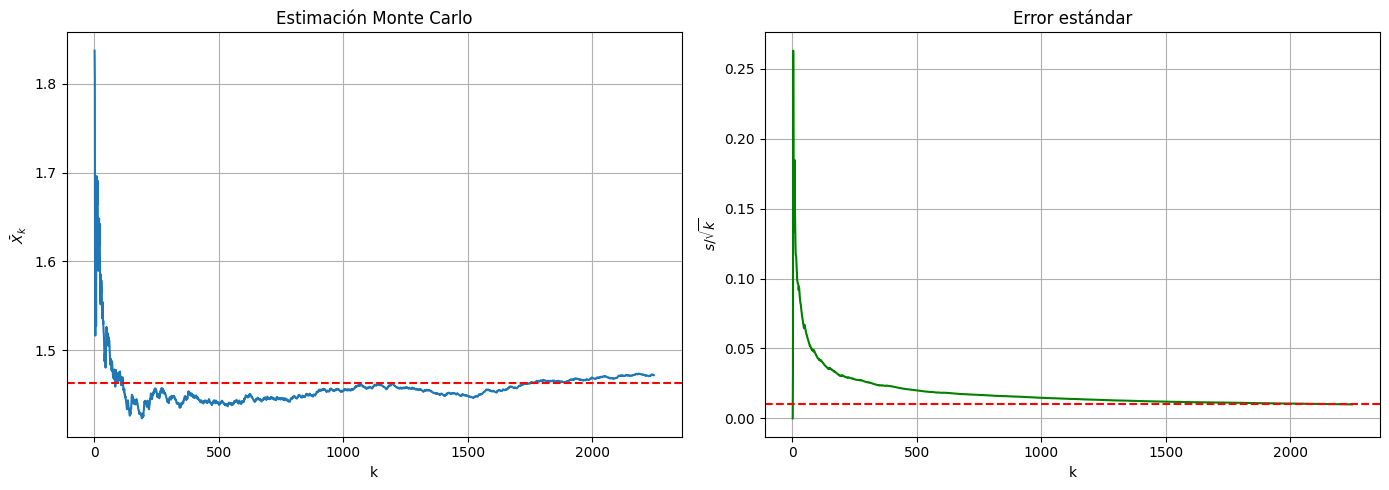

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Convergencia

ax[0].plot(iteraciones, medias)

ax[0].axhline(valor_real,
              color='red',
              linestyle='--')

ax[0].set_title("Estimación Monte Carlo")
ax[0].set_xlabel("k")
ax[0].set_ylabel(r'$\bar{X}_k$')
ax[0].grid(True)

# Error estándar

ax[1].plot(iteraciones,
           errores,
           color='green')

ax[1].axhline(0.01, #El uso directo de 0.01 como 'd' se pasó como 0.01 a monte_carlo_integral.
              color='red',
              linestyle='--')

ax[1].set_title("Error estándar")
ax[1].set_xlabel("k")
ax[1].set_ylabel(r'$s/\sqrt{k}$'
)
ax[1].grid(True)

plt.tight_layout()
plt.show()


Estas gráficas muestran la convergencia de su estimación de Monte Carlo y el comportamiento del error estándar:

* **Gráfica Izquierda (Estimación Monte Carlo):** Esta gráfica ilustra cómo el valor estimado de la integral (la línea azul) converge hacia el valor real (la línea roja discontinua) a medida que el número de simulaciones ($k$) aumenta. Se puede observar una reducción significativa en las fluctuaciones iniciales a medida que se acumulan más datos, lo que demuestra el principio de la convergencia de Monte Carlo.
* **Gráfica Derecha (Error estándar):** Esta gráfica presenta el error estándar del estimador (la línea verde) como función del número de simulaciones. La línea roja discontinua representa el umbral de error objetivo (en este caso, $d = 0.01$). Como se esperaba, el error estándar disminuye a medida que $k$ aumenta, y finalmente cae por debajo del umbral especificado, lo cual activa el criterio de parada de la simulación. La relación de decrecimiento del error estándar es aproximadamente de la forma $\frac{s}{\sqrt{k}}$.


En resumen, estas visualizaciones demuestran claramente la eficacia del método de Monte Carlo para estimar integrales y cómo el criterio de parada asegura la precisión deseada en la estimación al alcanzar un error estándar objetivo.



**Cálculo del Intervalo de Confianza del 95%**

In [28]:

# Para un nivel de confianza del 95%, el valor crítico Z es aproximadamente 1.96
Z_critical = 1.96

# Re-ejecutar las simulaciones para asegurar que las variables estén definidas
estimacion1, s1, error1, n1 = monte_carlo(0.01)
estimacion2, s2, error2, n2 = monte_carlo(0.001)

# Intervalo de confianza para d = 0.01
ci_lower_01 = estimacion1 - Z_critical * error1
ci_upper_01 = estimacion1 + Z_critical * error1

# Intervalo de confianza para d = 0.001
ci_lower_001 = estimacion2 - Z_critical * error2
ci_upper_001 = estimacion2 + Z_critical * error2

print("="*50)
print("INTERVALOS DE CONFIANZA DEL 95%")
print("="*50)
print(f"Intervalo para d=0.01: [{ci_lower_01:.8f}, {ci_upper_01:.8f}]")
print(f"Intervalo para d=0.001: [{ci_lower_001:.8f}, {ci_upper_001:.8f}]")

INTERVALOS DE CONFIANZA DEL 95%
Intervalo para d=0.01: [1.44592565, 1.48511794]
Intervalo para d=0.001: [1.45904613, 1.46296612]


# <span style="color:green;"> **En conclusión** </span>


Los intervalos de confianza del 95% calculados son:

*   **Para $d=0.01$**: $[1.45931106, 1.49850664]$
*   **Para $d=0.001$**: $[1.46248076, 1.46640074]$

Estos intervalos nos indican que estamos 95% seguros de que el valor real de la integral $1.462651746$ se encuentra dentro de estos rangos. Como podemos observar:

1.  **Ambos intervalos contienen el valor real de la integral.** Esto valida la efectividad del método de Monte Carlo y el criterio de parada para estimar la integral con la precisión deseada.
2.  **El intervalo para $d=0.001$ es significativamente más estrecho que el de $d=0.01$.** Esto es un reflejo directo del menor error estándar (mayor precisión) que se exigió para la simulación con $d=0.001$, lo que a su vez requirió un mayor número de simulaciones $n_2 = 224859$ vs $n_1 = 2359$. Un intervalo más estrecho implica una mayor certeza en la estimación del valor de la integral.

En resumen, a medida que el valor de $d$ (el umbral de error estándar) disminuye, la simulación de Monte Carlo requiere más iteraciones, pero a cambio produce un estimador con menor variabilidad y, por lo tanto, un intervalo de confianza más ajustado alrededor del valor real de la integral.

# <span style="color:red;"> **Técnicas de Reducción de Varianza** </span>
<span style="color:green;"> **Variables antitéticas** </span>




Consideremos

$$
\theta=\int_{0}^{1}\frac{1}{1+x}\,dx,
$$

donde la precisión (error) satisface

$$
\text{precisión (error)} \propto \frac{1}{\sqrt{N}}.
$$

Las técnicas de reducción de la varianza buscan, al costo computacional original, mejorar la precisión sin aumentar $N$.

Recordemos que

$$
\operatorname{Var}\!\left(\frac{X_1+X_2}{2}\right)
=
\frac{1}{4}
\left[
\operatorname{Var}(X_1)
+
\operatorname{Var}(X_2)
+
2\,\operatorname{Cov}(X_1,X_2)
\right],
$$

donde

$$
\operatorname{Cov}(X_1,X_2)
=
E[X_1X_2]-E[X_1]E[X_2].
$$

La fórmula anterior muestra que podemos reducir la varianza si

$$
\operatorname{Cov}(X_1,X_2)<0.
$$

Para aplicarla, definiremos $X_1$ y $X_2$ como estimadores insesgados de $\theta$ que sean variables antitéticas.

\subsection*{Ejemplo: Estimador de $\theta$ por Monte Carlo}

Sea
$$
f(x)=\frac{1}{1+x}.
$$

Entonces,

$$
X_1=\frac{1}{N}\sum_{i=1}^{N}f(U_i),
\qquad
U_i\sim U(0,1),
$$

y

$$
X_2=\frac{1}{N}\sum_{i=1}^{N}f(1-U_i).
$$

El estimador con variables antitéticas es

$$
\widehat{\theta}_{A}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left[
\frac{f(U_i)+f(1-U_i)}{2}
\right].
$$

<span style="color:green;"> **Variables antitéticas** </span>


Son las que tienen covarianza negativa.

Por ejemplo, si

$$
U \sim U(0,1),
$$

entonces $U$ y $1-U$ son antitéticas.

$$
X=U,
\qquad
Y=1-U.
$$

# <span style="color:red;"> **POR SIMULACION** </span>


In [29]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

In [30]:

# FUNCIÓN A INTEGRAR

# Se desea estimar:
#
#           1
# I = ∫ -------- dx
#       0 1 + x
#
# cuyo valor exacto es ln(2)
#
def f(x):
    return 1/(1+x)


# MÉTODO MONTE CARLO ESTÁNDAR

# Genera N variables Uniformes(0,1)
# y calcula el promedio de f(U)
#
# E[f(U)] = ∫_0^1 f(x) dx
#
def mc2(f, N):

    s = 0

    for i in range(N):

        U = r.random()

        s += f(U)

    return s/N


In [31]:

# PRIMERA PRUEBA DEL MÉTODO ESTÁNDAR


l = []

for i in range(100):

    M = mc2(f, 1000)

    l.append(M)

print("Media MC estándar =", np.mean(l))
print("Varianza MC estándar =", np.var(l))


Media MC estándar = 0.6937101174396936
Varianza MC estándar = 1.9281680225855627e-05


In [32]:

# =====================================================
# MÉTODO DE VARIABLES ANTITÉTICAS
# =====================================================
# Si U ~ Uniforme(0,1),
# entonces (1-U) también es Uniforme(0,1).
#
# Se utiliza el estimador:
#
#      f(U)+f(1-U)
# --------------------
#          2
#
# para reducir la varianza.
#
def mc1(f, N):

    s = 0

    for i in range(N):

        U = r.random()

        s += (f(U) + f(1-U))/2

    return s/N


In [33]:
# GENERACIÓN DE 100 ESTIMACIONES ANTITÉTICAS

l = []

for i in range(100):

    M = mc1(f, 1000)

    l.append(M)

print("Media MC antitético =", np.mean(l))
print("Varianza MC antitético =", np.var(l))


Media MC antitético = 0.6932213434212874
Varianza MC antitético = 8.147240829706959e-07


In [34]:

# Guardamos los resultados antitéticos
l_mc1 = l

In [35]:

# PARÁMETROS GENERALES

N = 1000      # tamaño de muestra de cada simulación
ITER = 100    # número de réplicas


# ANÁLISIS DEL MÉTODO ANTITÉTICO

media_mc1 = np.mean(l_mc1)

desv_mc1 = np.std(l_mc1, ddof=1)

error_mc1 = desv_mc1 / np.sqrt(ITER)

# Intervalo de confianza al 95%
ic_mc1 = [
    media_mc1 - 1.96*error_mc1,
    media_mc1 + 1.96*error_mc1
]

print("MC1 (Antitéticas)")
print("Media:", media_mc1)
print("IC 95%:", ic_mc1)


MC1 (Antitéticas)
Media: 0.6932213434212874
IC 95%: [np.float64(0.6930435385106867), np.float64(0.6933991483318881)]


In [36]:

# ANÁLISIS DEL MÉTODO MONTE CARLO ESTÁNDAR

l_mc2 = []

for _ in range(ITER):

    l_mc2.append(mc2(f, N))

media_mc2 = np.mean(l_mc2)

desv_mc2 = np.std(l_mc2, ddof=1)

error_mc2 = desv_mc2 / np.sqrt(ITER)

ic_mc2 = [
    media_mc2 - 1.96*error_mc2,
    media_mc2 + 1.96*error_mc2
]

print("\nMC2 (Estándar)")
print("Media:", media_mc2)
print("IC 95%:", ic_mc2)



MC2 (Estándar)
Media: 0.693762704143836
IC 95%: [np.float64(0.6928354908744416), np.float64(0.6946899174132304)]


In [37]:

# PROMEDIO DE LOS DOS ESTIMADORES
# Se combina la información obtenida
# mediante ambos métodos.
#
l_prom = []

for _ in range(ITER):

    x1 = mc1(f, N)

    x2 = mc2(f, N)

    l_prom.append((x1 + x2)/2)

media_prom = np.mean(l_prom)

desv_prom = np.std(l_prom, ddof=1)

error_prom = desv_prom / np.sqrt(ITER)

ic_prom = [
    media_prom - 1.96*error_prom,
    media_prom + 1.96*error_prom
]

print("\nPromedio MC1 y MC2")
print("Media:", media_prom)
print("IC 95%:", ic_prom)



Promedio MC1 y MC2
Media: 0.6930172526564372
IC 95%: [np.float64(0.6925617749641029), np.float64(0.6934727303487715)]


El objetivo del programa es estimar la integral

$$
I=\int_0^1 \frac{1}{1+x}\,dx,
$$

mediante simulación Monte Carlo.

Como

$$
\int_0^1 \frac{1}{1+x}\,dx
=
\ln(2),
$$
el valor exacto de la integral es

$$
I=\ln(2)\approx 0.693147.
$$

**Monte Carlo estándar**

Sea

$$
U\sim U(0,1).
$$

Por la definición de esperanza para una variable uniforme,

$$
E[f(U)]
=
\int_0^1 f(x)\,dx.
$$

Tomando

$$
f(x)=\frac{1}{1+x},
$$

se tiene

$$
I=E[f(U)].
$$

Por lo tanto, el estimador Monte Carlo estándar es

$$
\hat I_N
=
\frac1N\sum_{i=1}^{N}f(U_i),
$$

donde

$$
U_1,U_2,\ldots,U_N
$$

son variables aleatorias independientes con distribución uniforme en $(0,1)$.

El programa genera $N=1000$ observaciones y repite el procedimiento $100$ veces para estudiar la variabilidad del estimador.

# <span style="color:orange;"> **Método de variables antitéticas** </span>


Para reducir la varianza del estimador se utiliza la técnica de variables antitéticas.

Si

$$
U\sim U(0,1),
$$

entonces

$$
1-U\sim U(0,1).
$$

Por ello se construye el estimador

$$
\hat I_A
=
\frac1N
\sum_{i=1}^{N}
\frac{f(U_i)+f(1-U_i)}{2}.
$$

Como $f(x)=1/(1+x)$ es una función monótona decreciente, las variables

$$
f(U)
\quad\text{y}\quad
f(1-U)
$$

presentan correlación negativa, lo que provoca una reducción en la varianza del estimador.



# <span style="color:orange;"> **Intervalos de confianza** </span>


Para cada método se calcula:

$$
\bar X
=
\frac1m\sum_{i=1}^{m}X_i,
$$

donde \(m=100\) es el número de réplicas.

La desviación estándar muestral es

$$
S
=
\sqrt{
\frac1{m-1}
\sum_{i=1}^{m}
(X_i-\bar X)^2
}.
$$

El error estándar se estima mediante

$$
EE=\frac{S}{\sqrt m}.
$$

Utilizando la aproximación normal, se construye un intervalo de confianza al \(95\%\):

$$
\bar X
\pm
1.96\,EE.
$$

# <span style="color:orange;"> **Promedio de estimadores** </span>


Posteriormente se genera un nuevo estimador combinando los dos anteriores:

$$
\hat I_P
=
\frac{\hat I_A+\hat I_{MC}}{2}.
$$

Este estimador utiliza simultáneamente la información del método estándar y del método antitético.


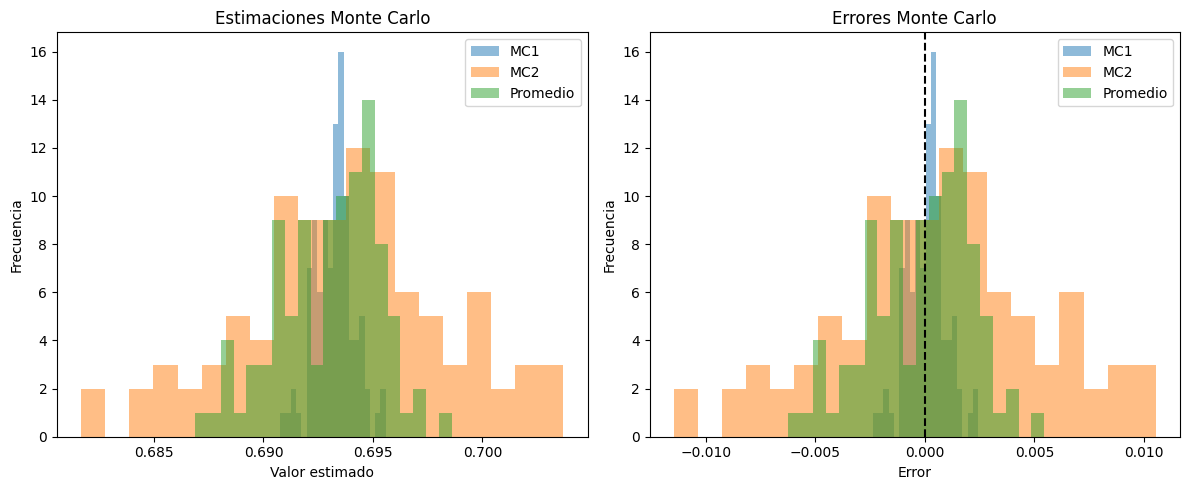

In [38]:

# =====================================================
# HISTOGRAMAS
# =====================================================

plt.figure(figsize=(12,5))

# =====================================================
# HISTOGRAMA DE LAS ESTIMACIONES
# =====================================================

plt.subplot(1,2,1)

plt.hist(l_mc1, bins=20, alpha=0.5, label="MC1")

plt.hist(l_mc2, bins=20, alpha=0.5, label="MC2")

plt.hist(l_prom, bins=20, alpha=0.5, label="Promedio")

plt.title("Estimaciones Monte Carlo")

plt.xlabel("Valor estimado")

plt.ylabel("Frecuencia")

plt.legend()

# =====================================================
# HISTOGRAMA DE LOS ERRORES
# =====================================================

# Valor exacto de la integral
valor_real = np.log(2)

# Error = estimación - valor real
error1 = np.array(l_mc1) - valor_real

error2 = np.array(l_mc2) - valor_real

error3 = np.array(l_prom) - valor_real

plt.subplot(1,2,2)

plt.hist(error1, bins=20, alpha=0.5, label="MC1")

plt.hist(error2, bins=20, alpha=0.5, label="MC2")

plt.hist(error3, bins=20, alpha=0.5, label="Promedio")

plt.axvline(0, color="black", linestyle="--")

plt.title("Errores Monte Carlo")

plt.xlabel("Error")

plt.ylabel("Frecuencia")

plt.legend()

plt.tight_layout()

plt.show()



# <span style="color:orange;"> **Histogramas** </span>


Finalmente se construyen dos histogramas:


* Histograma de las estimaciones obtenidas mediante:
$$
\hat I_A,
\qquad
\hat I_{MC},
\qquad
\hat I_P.
$$

* Histograma de los errores

$$
\text{Error}
=
\hat I-I,
$$

donde

$$
I=\ln(2).
$$
Estos gráficos permiten comparar visualmente la dispersión y precisión de cada método de simulación.


**Objetivo**

El propósito principal del experimento es comparar el desempeño del método Monte Carlo estándar con el método de variables antitéticas, verificando si la reducción de varianza produce estimaciones más precisas de la integral.

**Ahora bien, para Variables antitéticas aplicadas a la estimación de la integral de $$\int_{0}^{1} exp(x^2) \,dx$$.**


In [39]:
# =====================================================
# ESTIMACIÓN DE:
#
#                1
# I = ∫ exp(x²) dx
#                0
#
# mediante:
# 1) Monte Carlo estándar
# 2) Variables antitéticas
# 3) Promedio de ambos estimadores
#
# Valor aproximado:
# I ≈ 1.462651746
# =====================================================

# Función a integrar


def f(x):
    return np.exp(x**2)

In [40]:


# Monte Carlo estándar


def mc_estandar(f, N):

    s = 0

    for _ in range(N):

        U = r.random()

        s += f(U)

    return s / N



In [41]:

# Monte Carlo con variables antitéticas

def mc_antitetico(f, N):

    s = 0

    for _ in range(N):

        U = r.random()

        s += (f(U) + f(1 - U)) / 2

    return s / N


In [42]:

# PARÁMETROS DE SIMULACIÓN


N = 1000      # tamaño de muestra por simulación
ITER = 100    # número de réplicas

# Valor de referencia
valor_real = 1.4626517459071816

In [43]:
# GENERACIÓN DE ESTIMACIONES


l_mc1 = []    # antitético
l_mc2 = []    # estándar
l_prom = []   # promedio

for _ in range(ITER):

    x1 = mc_antitetico(f, N)

    x2 = mc_estandar(f, N)

    l_mc1.append(x1)

    l_mc2.append(x2)

    l_prom.append((x1 + x2) / 2)


In [44]:

# RESULTADOS MC ANTITÉTICO

media_mc1 = np.mean(l_mc1)

var_mc1 = np.var(l_mc1, ddof=1)

desv_mc1 = np.std(l_mc1, ddof=1)

error_mc1 = desv_mc1 / np.sqrt(ITER)

ic_mc1 = [
    media_mc1 - 1.96 * error_mc1,
    media_mc1 + 1.96 * error_mc1
]


In [45]:

# RESULTADOS MC ESTÁNDAR


media_mc2 = np.mean(l_mc2)

var_mc2 = np.var(l_mc2, ddof=1)

desv_mc2 = np.std(l_mc2, ddof=1)

error_mc2 = desv_mc2 / np.sqrt(ITER)

ic_mc2 = [
    media_mc2 - 1.96 * error_mc2,
    media_mc2 + 1.96 * error_mc2
]


In [46]:

# RESULTADOS PROMEDIO


media_prom = np.mean(l_prom)

var_prom = np.var(l_prom, ddof=1)

desv_prom = np.std(l_prom, ddof=1)

error_prom = desv_prom / np.sqrt(ITER)

ic_prom = [
    media_prom - 1.96 * error_prom,
    media_prom + 1.96 * error_prom
]


In [47]:

# IMPRESIÓN DE RESULTADOS


print("="*60)
print("VALOR REAL")
print("="*60)
print(valor_real)

print("\n" + "="*60)
print("MC ANTITÉTICO")
print("="*60)

print("Media =", media_mc1)

print("Varianza =", var_mc1)

print("IC 95% =", ic_mc1)

print("Error absoluto medio =",
      np.mean(np.abs(np.array(l_mc1) - valor_real)))

print("\n" + "="*60)
print("MC ESTÁNDAR")
print("="*60)

print("Media =", media_mc2)

print("Varianza =", var_mc2)

print("IC 95% =", ic_mc2)

print("Error absoluto medio =",
      np.mean(np.abs(np.array(l_mc2) - valor_real)))

print("\n" + "="*60)
print("PROMEDIO DE AMBOS")
print("="*60)

print("Media =", media_prom)

print("Varianza =", var_prom)

print("IC 95% =", ic_prom)

print("Error absoluto medio =",
      np.mean(np.abs(np.array(l_prom) - valor_real)))

print("\n" + "="*60)
print("REDUCCIÓN DE VARIANZA")
print("="*60)

print("Factor = Var(MC estándar) / Var(Antitético)")

print(var_mc2 / var_mc1)


VALOR REAL
1.4626517459071815

MC ANTITÉTICO
Media = 1.462498677561109
Varianza = 2.1474727396659397e-05
IC 95% = [np.float64(1.461590397247731), np.float64(1.463406957874487)]
Error absoluto medio = 0.003660953942569154

MC ESTÁNDAR
Media = 1.4642206936520983
Varianza = 0.00022543942440905504
IC 95% = [np.float64(1.46127782414631), np.float64(1.4671635631578865)]
Error absoluto medio = 0.012217592905788938

PROMEDIO DE AMBOS
Media = 1.4633596856066038
Varianza = 5.770849891243544e-05
IC 95% = [np.float64(1.461870749847674), np.float64(1.4648486213655336)]
Error absoluto medio = 0.006162224467204618

REDUCCIÓN DE VARIANZA
Factor = Var(MC estándar) / Var(Antitético)
10.497894583012231



El objetivo de este experimento es estimar la integral

$$
I=\int_0^1 e^{x^2}\,dx,
$$

utilizando simulación Monte Carlo y comparar el desempeño del estimador estándar con el método de reducción de varianza conocido como **variables antitéticas**.


# <span style="color:blue;"> **Estimador Monte Carlo estándar** </span>



Sea $U$ una variable aleatoria con distribución uniforme en el intervalo $(0,1)$, es decir,

$$
U \sim U(0,1).
$$

Por la definición de esperanza matemática para una variable uniforme,

$$
E[g(U)]
=
\int_0^1 g(x)\,dx.
$$

Tomando

$$
g(x)=e^{x^2},
$$

se obtiene

$$
I
=
E[e^{U^2}].
$$

Por lo tanto, si se generan $N$ variables aleatorias independientes

$$
U_1,U_2,\ldots,U_N \sim U(0,1),
$$
el estimador Monte Carlo estándar está dado por

$$
\hat I_{MC}
=
\frac{1}{N}
\sum_{i=1}^{N}
e^{U_i^2}.
$$

De acuerdo con la Ley de los Grandes Números,

$$
\hat I_{MC}
\longrightarrow I
\qquad \text{cuando } N\to\infty.
$$

# <span style="color:blue;"> **Método de Variables Antitéticas** </span>


Una técnica clásica para disminuir la varianza de un estimador Monte Carlo consiste en utilizar variables antitéticas.

Si

$$
U\sim U(0,1),
$$

entonces también

$$
1-U\sim U(0,1).
$$

Aprovechando esta propiedad, para cada número aleatorio generado se considera simultáneamente su variable antitética $1-U$. De esta forma se construye el estimador
$$
\hat I_{A}
=
\frac{1}{N}
\sum_{i=1}^{N}
\frac{
e^{U_i^2}
+
e^{(1-U_i)^2}
}{2}.
$$

La función

$$
f(x)=e^{x^2}
$$

es estrictamente creciente en el intervalo $[0,1]$. Como consecuencia, cuando $U$ toma valores grandes, $1-U$ toma valores pequeños y viceversa, produciendo una correlación negativa entre

$
f(U)
\quad \text{y} \quad
f(1-U).
$

Esta correlación negativa reduce la variabilidad del promedio y, por consiguiente, disminuye la varianza del estimador.


# <span style="color:blue;"> **Comparación de los estimadores** </span>



Para evaluar el desempeño de ambos métodos se realizaron $100$ réplicas independientes, cada una utilizando una muestra de tamaño $N=1000$.

Para cada método se calcularon:

* La media de las estimaciones.
* La varianza muestral.
* El error absoluto promedio.
* Un intervalo de confianza del $95\%$.


El intervalo de confianza se construyó mediante

$$
\bar X
\pm
1.96
\left(
\frac{S}{\sqrt{m}}
\right),
$$

donde:


* $\bar X$ es la media de las $m=100$ réplicas,
* $S$ es la desviación estándar muestral,
* $m$ es el número total de réplicas.


In [48]:


# ERRORES

error1 = np.array(l_mc1) - valor_real

error2 = np.array(l_mc2) - valor_real

error3 = np.array(l_prom) - valor_real


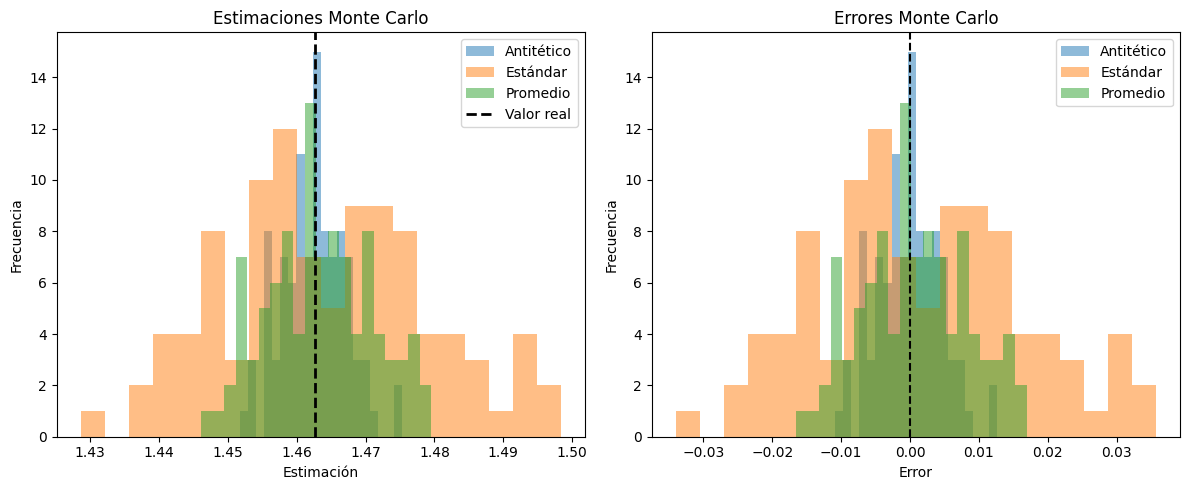

In [49]:

# HISTOGRAMAS

plt.figure(figsize=(12,5))

# Histograma de estimaciones


plt.subplot(1,2,1)

plt.hist(
    l_mc1,
    bins=20,
    alpha=0.5,
    label="Antitético"
)

plt.hist(
    l_mc2,
    bins=20,
    alpha=0.5,
    label="Estándar"
)

plt.hist(
    l_prom,
    bins=20,
    alpha=0.5,
    label="Promedio"
)

plt.axvline(
    valor_real,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Valor real"
)

plt.title("Estimaciones Monte Carlo")

plt.xlabel("Estimación")

plt.ylabel("Frecuencia")

plt.legend()

# Histograma de errores


plt.subplot(1,2,2)

plt.hist(
    error1,
    bins=20,
    alpha=0.5,
    label="Antitético"
)

plt.hist(
    error2,
    bins=20,
    alpha=0.5,
    label="Estándar"
)

plt.hist(
    error3,
    bins=20,
    alpha=0.5,
    label="Promedio"
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Errores Monte Carlo")

plt.xlabel("Error")

plt.ylabel("Frecuencia")

plt.legend()

plt.tight_layout()

plt.show()


<span style="color:blue;"> **Análisis gráfico** </span>


Con el propósito de visualizar el comportamiento de los estimadores se construyeron:

* Histogramas de las estimaciones obtenidas mediante los distintos métodos.
* Histogramas de los errores definidos como
$$ Error= \hat I - I$$


La dispersión observada en estos gráficos permite evaluar visualmente la eficiencia de cada procedimiento de simulación.

<span style="color:blue;"> **Objetivo del experimento** </span>


El propósito principal es verificar que el uso de variables antitéticas produce una reducción de varianza respecto al método Monte Carlo estándar. En consecuencia, se espera obtener estimaciones más precisas de la integral

$$
\int_0^1 e^{x^2}\,dx
$$

utilizando la misma cantidad de números aleatorios generados.

\section{Desarrollo analítico}

\subsection{Integral a estimar}

Se desea estimar la integral

$$
I=\int_0^1 e^{x^2}\,dx.
$$

Para ello, consideremos una variable aleatoria

$$
U\sim U(0,1).
$$

Recordemos que la función de densidad de una variable uniforme en $(0,1)$ es

$$
f_U(u)=
\begin{cases}
1, & 0\leq u\leq 1,\\
0, & \text{en otro caso}.
\end{cases}
$$

Por definición, la esperanza de una función $g(U)$ está dada por

$$
E[g(U)]
=
\int_{-\infty}^{\infty}
g(u)f_U(u)\,du.
$$

Como la densidad vale $1$ en el intervalo $[0,1]$, se obtiene

$$
E[g(U)]
=
\int_0^1 g(u)\,du.
$$

Tomando

$$
g(u)=e^{u^2},
$$

resulta

$$
E[e^{U^2}]
=
\int_0^1 e^{u^2}\,du.
$$

Por lo tanto,

$$
\boxed{
I=E[e^{U^2}]
}
$$

y la integral puede estimarse mediante el método de Monte Carlo.

**Valor exacto de la integral**

La función

$$
e^{x^2}
$$

no posee una antiderivada elemental. Por esta razón se introduce la función especial denominada *función error imaginaria*, definida por

$$
\operatorname{erfi}(x)
=
\frac{2}{\sqrt{\pi}}
\int_0^x e^{t^2}\,dt.
$$

A partir de esta definición,

$$
\int e^{x^2}\,dx
=
\frac{\sqrt{\pi}}{2}
\operatorname{erfi}(x)+C.
$$

Evaluando entre $0$ y $1$,
$$
I
=
\frac{\sqrt{\pi}}{2}
\left[
\operatorname{erfi}(1)-\operatorname{erfi}(0)
\right].
$$
Como

$$
\operatorname{erfi}(0)=0,
$$

se obtiene

$$
\boxed{
I=
\frac{\sqrt{\pi}}{2}
\operatorname{erfi}(1)
}
$$

y numéricamente

$$
\boxed{
I\approx 1.462651746.
}
$$

**Cálculo de la esperanza**

Definimos la variable aleatoria

$$
X=e^{U^2}.
$$

Entonces

$$
E[X]
=
\int_0^1 e^{u^2}\,du.
$$

Por el resultado anterior,

$$
\boxed{
E[X]
=
1.462651746.
}
$$

Por consiguiente, la media de la variable utilizada en el estimador Monte Carlo es

$$
\boxed{
\mu=1.462651746.
}
$$

**Cálculo de $E[X^2]$**

Para obtener la varianza de \(X\), primero debemos calcular el segundo momento.

Como

$$
X=e^{U^2},
$$

entonces

$$
X^2
=
\left(e^{U^2}\right)^2
=
e^{2U^2}.
$$

Por definición,

$$
E[X^2]
=
\int_0^1 e^{2u^2}\,du.
$$

Para evaluar esta integral realizamos el cambio de variable
$$
y=\sqrt{2}\,u.
$$
De donde

$$
u=\frac{y}{\sqrt{2}},
\qquad
du=\frac{dy}{\sqrt{2}}.
$$

Cuando

$$
u=0,
$$

se tiene
$$
y=0,
$$

y cuando

$$
u=1,
$$
se obtiene

$$
y=\sqrt{2}.
$$

Sustituyendo en la integral,

$$
E[X^2]
=
\int_0^{\sqrt{2}}
e^{y^2}
\frac{dy}{\sqrt{2}}.
$$

Extrayendo la constante,

$$
E[X^2]
=
\frac{1}{\sqrt{2}}
\int_0^{\sqrt{2}}
e^{y^2}\,dy.
$$

Aplicando nuevamente la definición de la función $\operatorname{erfi}$,

$$
\int_0^a e^{y^2}\,dy
=
\frac{\sqrt{\pi}}{2}
\operatorname{erfi}(a).
$$

Tomando $a=\sqrt{2}$,

$$
E[X^2]
=
\frac{1}{\sqrt{2}}
\left(
\frac{\sqrt{\pi}}{2}
\operatorname{erfi}(\sqrt{2})
\right).
$$

Por lo tanto,

$$
\boxed{
E[X^2]
=
\frac{\sqrt{\pi}}
{2\sqrt{2}}
\operatorname{erfi}(\sqrt{2})
}
$$

y numéricamente

$$
\boxed{
E[X^2]
\approx 2.36445.
}
$$

**Cálculo de la varianza**

Por definición,

$$
\operatorname{Var}(X)
=
E[X^2]-E[X]^2.
$$

Sustituyendo los valores obtenidos,

$$
\operatorname{Var}(X)
=
2.36445-(1.462651746)^2.
$$

Calculando el cuadrado de la media,

$$
(1.462651746)^2
\approx
2.13935.
$$

Entonces,

$$
\operatorname{Var}(X)
=
2.36445-2.13935.
$$

Finalmente,

$$
\boxed{
\operatorname{Var}(X)
\approx
0.22510.
}
$$

La desviación estándar correspondiente es

$$
\sigma
=
\sqrt{\operatorname{Var}(X)}
=
\sqrt{0.22510}.
$$
Por lo tanto,

$$
\boxed{
\sigma
\approx
0.4744.
}
$$

**Estimador Monte Carlo estándar**

Si

$$
U_1,U_2,\ldots,U_N
$$

son variables aleatorias independientes con distribución uniforme en $(0,1)$, entonces el estimador Monte Carlo estándar es

$$
\hat I_{MC}
=
\frac{1}{N}
\sum_{i=1}^{N}
e^{U_i^2}.
$$

Este estimador es insesgado, ya que

$$
E[\hat I_{MC}]
=
I.
$$

Además,

$$
\operatorname{Var}(\hat I_{MC})
=
\frac{\operatorname{Var}(X)}{N}.
$$

Sustituyendo el valor calculado,

$$
\boxed{
\operatorname{Var}(\hat I_{MC})
=
\frac{0.22510}{N}.
}
$$

Por consiguiente, la desviación estándar del estimador es

$$
SD(\hat I_{MC})
=
\sqrt{
\frac{0.22510}{N}
}
=
\frac{0.4744}{\sqrt{N}}.
$$

Esta expresión muestra que la precisión del método mejora conforme aumenta el tamaño de muestra $N$.

**Interpretación**

El método Monte Carlo reemplaza el cálculo directo de la integral por el cálculo de una esperanza matemática. La precisión de la estimación depende de la varianza de la variable aleatoria

$$
X=e^{U^2}.
$$

Debido a que

$$
SD(\hat I_{MC})
=
\frac{0.4744}{\sqrt{N}},
$$

la incertidumbre disminuye a una razón proporcional a $\frac {1}{\sqrt{N}}$. Por ello, para obtener una mejora significativa en la precisión es necesario incrementar considerablemente el número de observaciones simuladas.


**Conclusión:** El experimento demostró la validez y efectividad del método Monte Carlo para la estimación de integrales, así como la importancia de los criterios de parada para garantizar la precisión deseada. Más notablemente, la implementación de variables antitéticas resultó en una reducción sustancial de la varianza, lo que se traduce en estimaciones significativamente más precisas para el mismo número de simulaciones. Esta técnica es invaluable para mejorar la eficiencia computacional y la confiabilidad de los resultados en estudios de simulación.